# Chapter 12: AI for Clinical and Translational Oncology

## Hands-On Jupyter Notebook

This notebook simulates translational oncology decision support using synthetic patient cohorts, biomarker matching, and trial-selection rules.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A small synthetic cohort with clinical context
- A translational trial-matching table
- Risk and action summaries for patient triage
- Exercises for tiering and report generation

---

## Section 1: Setup and Imports

We prepare a deterministic clinical translation simulation with clear tabular outputs.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 12 clinical/translational notebook.')

Environment configured for Chapter 12 clinical/translational notebook.


## Section 2: Synthetic Cohort and Trial Catalog

We define a small cohort and a trial catalog to demonstrate translational matching.

In [2]:
cohort_df = pd.DataFrame(
    [
        {'patient_id': 'pt_01', 'diagnosis': 'NSCLC', 'biomarker': 'EGFR', 'stage': 'IV', 'risk_level': 'high', 'site': 'thoracic'},
        {'patient_id': 'pt_02', 'diagnosis': 'CRC', 'biomarker': 'BRAF', 'stage': 'III', 'risk_level': 'medium', 'site': 'gastrointestinal'},
        {'patient_id': 'pt_03', 'diagnosis': 'Breast cancer', 'biomarker': 'ERBB2', 'stage': 'II', 'risk_level': 'medium', 'site': 'breast'},
        {'patient_id': 'pt_04', 'diagnosis': 'Glioma', 'biomarker': 'H3F3A', 'stage': 'IV', 'risk_level': 'high', 'site': 'neuro-oncology'},
        {'patient_id': 'pt_05', 'diagnosis': 'NSCLC', 'biomarker': 'ALK', 'stage': 'III', 'risk_level': 'medium', 'site': 'thoracic'},
    ]
)

trial_df = pd.DataFrame(
    [
        {'trial_id': 'trial_A', 'biomarker': 'EGFR', 'phase': 'II', 'focus': 'targeted therapy'},
        {'trial_id': 'trial_B', 'biomarker': 'BRAF', 'phase': 'II', 'focus': 'combo therapy'},
        {'trial_id': 'trial_C', 'biomarker': 'ERBB2', 'phase': 'III', 'focus': 'antibody therapy'},
        {'trial_id': 'trial_D', 'biomarker': 'ALK', 'phase': 'II', 'focus': 'targeted therapy'},
    ]
)

display(cohort_df)
display(trial_df)

,patient_id,diagnosis,biomarker,stage,risk_level,site
0,pt_01,NSCLC,EGFR,IV,high,thoracic
1,pt_02,CRC,BRAF,III,medium,gastrointestinal
2,pt_03,Breast cancer,ERBB2,II,medium,breast
3,pt_04,Glioma,H3F3A,IV,high,neuro-oncology
4,pt_05,NSCLC,ALK,III,medium,thoracic


,trial_id,biomarker,phase,focus
0,trial_A,EGFR,II,targeted therapy
1,trial_B,BRAF,II,combo therapy
2,trial_C,ERBB2,III,antibody therapy
3,trial_D,ALK,II,targeted therapy


## Section 3: Translational Matching

We combine cohort context and biomarker eligibility to derive a simple translational recommendation.

In [3]:
translational_df = cohort_df.merge(trial_df, on='biomarker', how='left')
translational_df['eligibility'] = np.where(translational_df['trial_id'].notna(), 'trial_match', 'no_direct_match')
translational_df['action'] = np.where(
    translational_df['eligibility'] == 'trial_match',
    'review_for_enrollment',
    'consider_off_label_or_biopsy_retest',
)
translational_df['priority_score'] = np.select(
    [translational_df['risk_level'].eq('high'), translational_df['risk_level'].eq('medium')],
    [3, 2],
    default=1,
)

display(translational_df[['patient_id', 'diagnosis', 'biomarker', 'trial_id', 'eligibility', 'action', 'priority_score']])

,patient_id,diagnosis,biomarker,trial_id,eligibility,action,priority_score
0,pt_01,NSCLC,EGFR,trial_A,trial_match,review_for_enrollment,3
1,pt_02,CRC,BRAF,trial_B,trial_match,review_for_enrollment,2
2,pt_03,Breast cancer,ERBB2,trial_C,trial_match,review_for_enrollment,2
3,pt_04,Glioma,H3F3A,NaN,no_direct_match,consider_off_label_or_biopsy_retest,3
4,pt_05,NSCLC,ALK,trial_D,trial_match,review_for_enrollment,2


## Section 4: Visualization

We visualize matching outcomes and the distribution of translational priorities across the cohort.

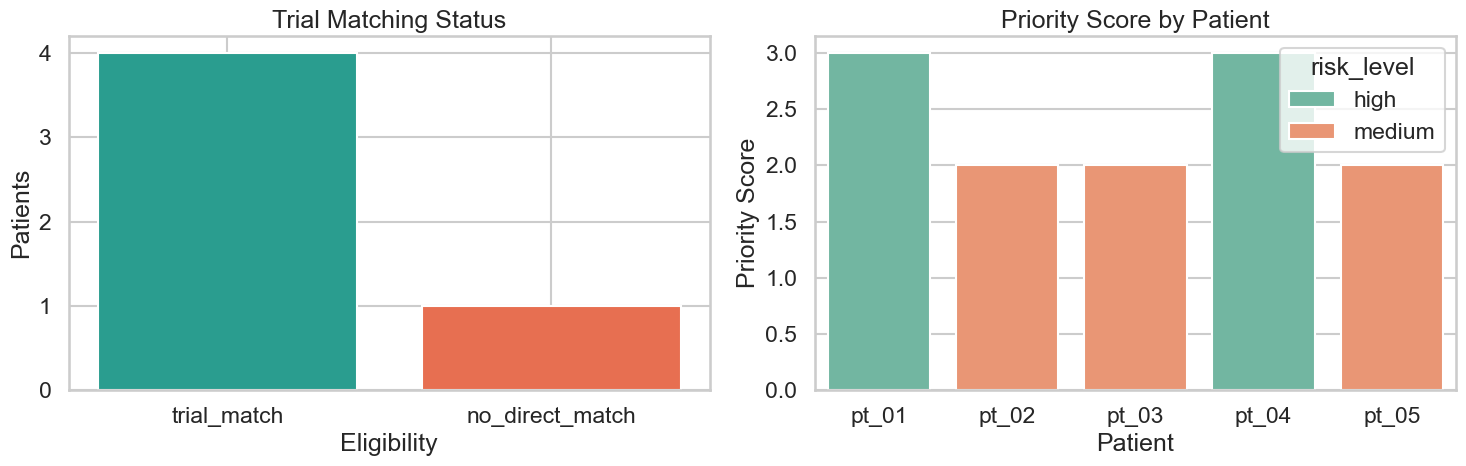

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

match_counts = translational_df['eligibility'].value_counts()
axes[0].bar(match_counts.index, match_counts.values, color=['#2A9D8F', '#E76F51'])
axes[0].set_title('Trial Matching Status')
axes[0].set_xlabel('Eligibility')
axes[0].set_ylabel('Patients')

sns.barplot(data=translational_df, x='patient_id', y='priority_score', hue='risk_level', ax=axes[1], palette='Set2')
axes[1].set_title('Priority Score by Patient')
axes[1].set_xlabel('Patient')
axes[1].set_ylabel('Priority Score')

plt.tight_layout()
plt.show()

## Section 5: Exercises

### Exercise 1: Translational Triage Tier

Assign each patient to a triage tier using risk level and matching status.

In [5]:
def triage_tier(row: pd.Series) -> str:
    if row['risk_level'] == 'high' and row['eligibility'] == 'trial_match':
        return 'urgent_trial_review'
    if row['risk_level'] == 'high':
        return 'urgent_clinical_review'
    if row['eligibility'] == 'trial_match':
        return 'standard_trial_review'
    return 'molecular_follow_up'

triage_df = translational_df[['patient_id', 'risk_level', 'eligibility']].copy()
triage_df['triage_tier'] = translational_df.apply(triage_tier, axis=1)

display(triage_df)

,patient_id,risk_level,eligibility,triage_tier
0,pt_01,high,trial_match,urgent_trial_review
1,pt_02,medium,trial_match,standard_trial_review
2,pt_03,medium,trial_match,standard_trial_review
3,pt_04,high,no_direct_match,urgent_clinical_review
4,pt_05,medium,trial_match,standard_trial_review


### Exercise 2: Translational Summary Writer

Create a compact summary of the recommended next step for each patient.

In [6]:
summary_rows = []
for _, row in translational_df.iterrows():
    summary_rows.append({
        'patient_id': row['patient_id'],
        'summary': f"{row['diagnosis']} patient with {row['biomarker']} biomarker should {row['action']}.",
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,patient_id,summary
0,pt_01,NSCLC patient with EGFR biomarker should revie...
1,pt_02,CRC patient with BRAF biomarker should review_...
2,pt_03,Breast cancer patient with ERBB2 biomarker sho...
3,pt_04,Glioma patient with H3F3A biomarker should con...
4,pt_05,NSCLC patient with ALK biomarker should review...


## Section 6: Key Takeaways

- Translational oncology workflows depend on biomarker-aware triage and matching.
- Trial eligibility should be surfaced explicitly rather than buried in prose.
- Priority scoring helps teams review high-risk cases first.
- Compact recommendation summaries are easier to hand off to clinical reviewers.
- Synthetic cohort tables make the workflow safe to prototype offline.


## Next Steps

1. Add additional biomarkers and resistance markers.
2. Extend trial matching with exclusion criteria and line-of-therapy rules.
3. Connect Chapter 12 recommendations to Chapter 13 evaluation metrics.
4. Replace the synthetic cohort with study-specific clinical registry data.


**Last Updated**: May 2026